# Manutenção Preditiva Não Supervisionada - MetroPT-3

Este notebook apresenta uma abordagem não supervisionada baseada em **Agrupamento (K-Means)** para monitorar e prever falhas no compressor de ar de um trem metropolitano (MetroPT-3).

Em vez de treinar classificadores para prever falhas a partir de pouquíssimos exemplos históricos (apenas 4 falhas em 15 milhões de registros), esta abordagem:
1. Agrupa as leituras dos sensores em estados operacionais físicos.
2. Identifica o estado "Sob Carga" (pumping air).
3. Constrói um **Indicador de Saúde** contínuo baseado no tempo de atividade sob carga.
4. Gera alertas preditivos horas antes de as falhas mecânicas ocorrerem.


In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

DATA_PATH = Path('metropt+3+dataset/MetroPT3(AirCompressor).csv')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)
DATA_PATH


WindowsPath('metropt+3+dataset/MetroPT3(AirCompressor).csv')

## 1. Leitura dos Dados

Carregamos as variáveis dos sensores e ordenamos o dataset cronologicamente.


In [ ]:
sensor_cols = [
    'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature',
    'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
    'Pressure_switch', 'Oil_level', 'Caudal_impulses'
]

dtype_map = {col: 'float32' for col in sensor_cols}

df = pd.read_csv(
    DATA_PATH,
    usecols=['timestamp'] + sensor_cols,
    parse_dates=['timestamp'],
    dtype=dtype_map
)

df = df.sort_values('timestamp').set_index('timestamp')
print('Dimensões dos dados originais (1Hz):', df.shape)
df.head()


Dimensões dos dados originais (1Hz): (1516948, 15)


,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.599998,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.674999,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.599998,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.424999,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.474998,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 2. Histórico de Falhas Reportadas (Verificação Física)

O dataset contém registros de 4 falhas críticas do tipo **Vazamento de Ar (Air leak)**:


In [ ]:
failure_windows = [
    ('2020-04-18 00:00:00', '2020-04-18 23:59:00', 'Air leak'),
    ('2020-05-29 23:30:00', '2020-05-30 06:00:00', 'Air leak'),
    ('2020-06-05 10:00:00', '2020-06-07 14:30:00', 'Air leak'),
    ('2020-07-15 14:30:00', '2020-07-15 19:00:00', 'Air leak'),
]

failures = pd.DataFrame(failure_windows, columns=['start', 'end', 'failure_type'])
failures['start'] = pd.to_datetime(failures['start'])
failures['end'] = pd.to_datetime(failures['end'])
failures


,start,end,failure_type
0,2020-04-18 00:00:00,2020-04-18 23:59:00,Air leak
1,2020-05-29 23:30:00,2020-05-30 06:00:00,Air leak
2,2020-06-05 10:00:00,2020-06-07 14:30:00,Air leak
3,2020-07-15 14:30:00,2020-07-15 19:00:00,Air leak


## 3. Agregação Temporal (Redução de Ruído)

Reduzimos a taxa de amostragem de 1Hz para **1 minuto** (calculando a média para sensores analógicos e a taxa média de ativação para sensores digitais). Isso suaviza picos espúrios e torna a análise computacionalmente viável.


In [ ]:
analog_cols = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Motor_current']
digital_cols = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

# Agregando por minuto
analog_agg = df[analog_cols].resample('1min').mean()
analog_agg.columns = [f'{col}_mean' for col in analog_agg.columns]

digital_agg = df[digital_cols].resample('1min').mean()
digital_agg.columns = [f'{col}_rate' for col in digital_agg.columns]

features = pd.concat([analog_agg, digital_agg], axis=1)
features = features.ffill().bfill()
print('Dimensões após agregação por minuto:', features.shape)
features.head()


Dimensões após agregação por minuto: (306960, 15)


,TP2_mean,TP3_mean,H1_mean,DV_pressure_mean,Reservoirs_mean,Oil_temperature_mean,Motor_current_mean,COMP_rate,DV_eletric_rate,Towers_rate,MPG_rate,LPS_rate,Pressure_switch_rate,Oil_level_rate,Caudal_impulses_rate
timestamp,,,,,,,,,,,,,,,
2020-02-01 00:00:00,-0.012286,9.327429,9.311143,-0.022857,9.328000,53.521427,0.040357,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:01:00,-0.013000,9.260000,9.243333,-0.023333,9.259666,53.420834,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:02:00,-0.012667,9.198334,9.182000,-0.022333,9.199000,53.325001,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:03:00,-0.012333,9.136666,9.120667,-0.022667,9.136666,53.200001,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2020-02-01 00:04:00,-0.013000,9.075667,9.060000,-0.023000,9.075667,53.129166,0.040000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


## 4. Agrupamento com K-Means (Estados Operacionais)

Normalizamos os dados agregados para que variáveis em escalas diferentes (como temperatura em °C e corrente em A) tenham pesos iguais. Em seguida, dividimos o comportamento em 4 clusters físicos.

Para garantir que a numeração dos clusters seja estável e previsível, remapeamos os índices dos clusters ordenando-os pelo consumo médio de corrente do motor (`Motor_current_mean`).


In [ ]:
# 1. Normalizar as variáveis
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 2. Treinar KMeans com K=4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
raw_clusters = kmeans.fit_predict(X_scaled)

# 3. Mapear os clusters para ordenar pelo consumo médio de corrente do motor
# (0 = Desligado, 1 = Atípico, 2 = Transição, 3 = Sob Carga)
temp_df = pd.DataFrame({'raw_cluster': raw_clusters, 'current': features['Motor_current_mean']})
mean_currents = temp_df.groupby('raw_cluster')['current'].mean().sort_values()
mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(mean_currents.index)}

features['cluster'] = raw_clusters
features['cluster'] = features['cluster'].map(mapping)
print('Clusters atribuídos e ordenados com sucesso de 0 a 3.')


Clusters atribuídos e ordenados com sucesso de 0 a 3.


## 5. Perfilamento Físico dos Clusters

Para entender o significado de cada grupo, calculamos a média das principais variáveis por cluster.


In [ ]:
profile = features.groupby('cluster')[
    ['Motor_current_mean', 'TP2_mean', 'TP3_mean', 'Reservoirs_mean', 'Oil_temperature_mean', 'COMP_rate']
].mean()
print('=== Perfil de Funcionamento por Cluster ===')
display(profile)


=== Perfil de Funcionamento por Cluster ===


,Motor_current_mean,TP2_mean,TP3_mean,Reservoirs_mean,Oil_temperature_mean,COMP_rate
cluster,,,,,,
0,0.131908,0.041896,8.672086,8.673477,59.133102,0.984240
1,1.064360,1.089331,5.333591,5.334766,45.554825,0.000141
2,3.617977,0.157757,9.613887,9.613843,66.879005,0.980195
3,5.490846,8.296295,8.869085,8.868437,66.285988,0.051833


### Interpretação Física dos Clusters Obtidos:

A partir dos valores médios acima, mapeamos cada cluster a um estado operacional estável do sistema:
* **Cluster 0**: **Compressor Desligado / Idle** (corrente próxima de 0A, sem pressão gerada no compressor TP2 ~ 0 bar, COMP ativo).
* **Cluster 1**: **Estado Atípico / Manutenção** (leituras com pressões e temperatura extremamente baixas, corrente ~1A).
* **Cluster 2**: **Transição / Vazio** (motor ligado com corrente intermediária ~3.6A, pressão TP2 baixa, válvula COMP ativa indicando que o compressor está descarregado).
* **Cluster 3**: **Compressor Sob Carga (Ativo)** (motor operando a corrente alta ~5.5A, pressão de saída TP2 elevada ~8.3 bar). Este é o estado operacional de maior estresse do compressor.


## 6. Criação do Indicador de Saúde do Compressor (Load Ratio)

Uma assinatura comum de vazamentos de ar é a permanência contínua sob carga: como o ar escapa, o compressor nunca atinge a pressão limite de desligamento e trabalha sem parar.
Criamos a métrica **Load Ratio**: a porcentagem de tempo em que o compressor passa ativo sob carga (Cluster 3) em uma **janela móvel de 24 horas** (1440 minutos).


In [ ]:
# 1. Criar variável binária que indica se o compressor está sob carga (Cluster 3)
features['is_loaded'] = (features['cluster'] == 3).astype(int)

# 2. Calcular a média móvel de 24 horas (1440 minutos) da atividade sob carga
# Isso nos dá o percentual do dia que o compressor passou trabalhando sob carga
features['load_ratio_24h'] = features['is_loaded'].rolling(window=1440, min_periods=60).mean() * 100

# 3. Adicionar uma variável para marcar momentos de falha real (para visualização nos gráficos)
features['is_failure'] = 0
for row in failures.itertuples(index=False):
    failure_mask = (features.index >= row.start) & (features.index <= row.end)
    features.loc[failure_mask, 'is_failure'] = 1

display(features[['is_loaded', 'load_ratio_24h', 'is_failure']].describe())


,is_loaded,load_ratio_24h,is_failure
count,306960.000000,306901.000000,306960.000000
mean,0.159962,15.994828,0.017113
std,0.366572,19.959080,0.129693
min,0.000000,0.000000,0.000000
25%,0.000000,6.388889,0.000000
50%,0.000000,9.930556,0.000000
75%,0.000000,13.958333,0.000000
max,1.000000,100.000000,1.000000


## 7. Visualização da Saúde do Compressor ao Longo do Tempo

Plotamos o **Load Ratio de 24h** contínuo de fevereiro a agosto. As falhas mecânicas reais reportadas estão representadas pelas faixas vermelhas verticais.


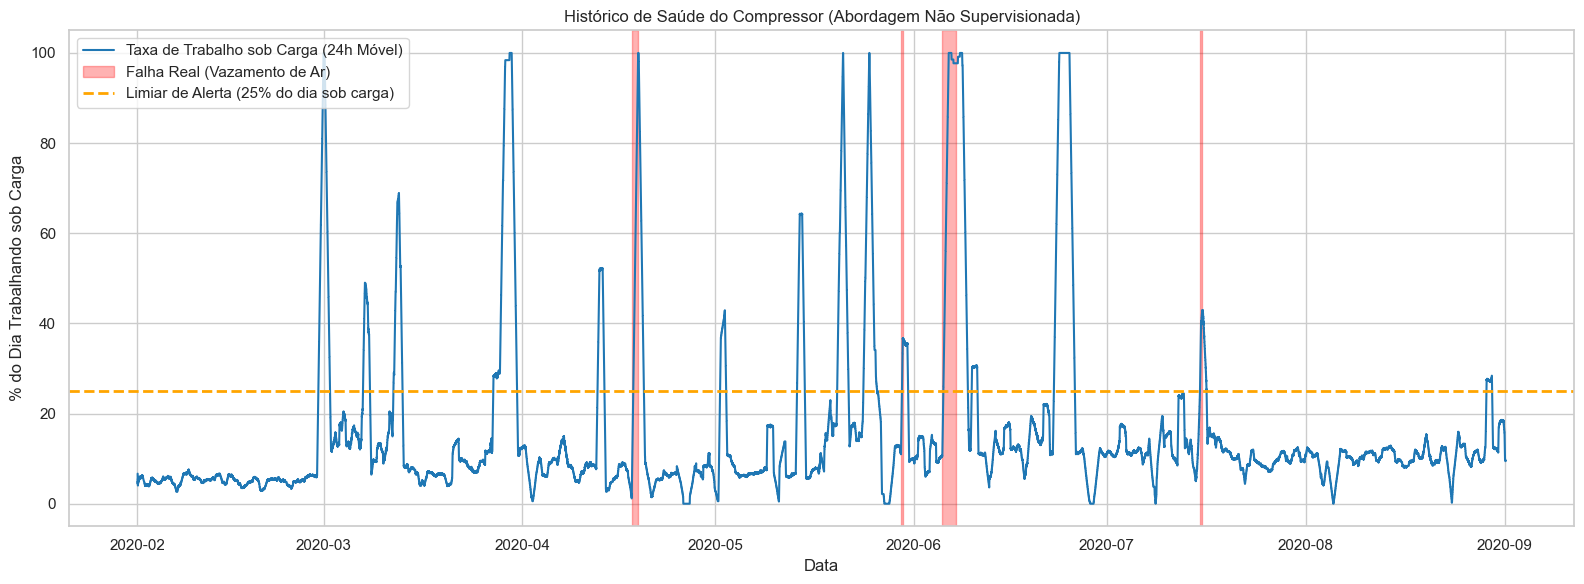

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))

# Plotar o indicador de saúde
ax.plot(features.index, features['load_ratio_24h'], label='Taxa de Trabalho sob Carga (24h Móvel)', color='#1f77b4', linewidth=1.5)

# Plotar faixas de falha real
first_failure = True
for row in failures.itertuples(index=False):
    ax.axvspan(row.start, row.end, color='red', alpha=0.3, 
              label='Falha Real (Vazamento de Ar)' if first_failure else '')
    first_failure = False

# Adicionar linha limite para Alerta de Manutenção (ex: 25% do dia sob carga)
ax.axhline(y=25, color='orange', linestyle='--', linewidth=2, label='Limiar de Alerta (25% do dia sob carga)')

ax.set_title('Histórico de Saúde do Compressor (Abordagem Não Supervisionada)')
ax.set_xlabel('Data')
ax.set_ylabel('% do Dia Trabalhando sob Carga')
ax.legend(loc='upper left')
ax.set_ylim(-5, 105)

plt.tight_layout()
plt.show()


## 8. Análise Detalhada dos Eventos de Falha

Podemos focar nas janelas de tempo individuais próximas a duas falhas para avaliar o comportamento do indicador antes da parada completa.


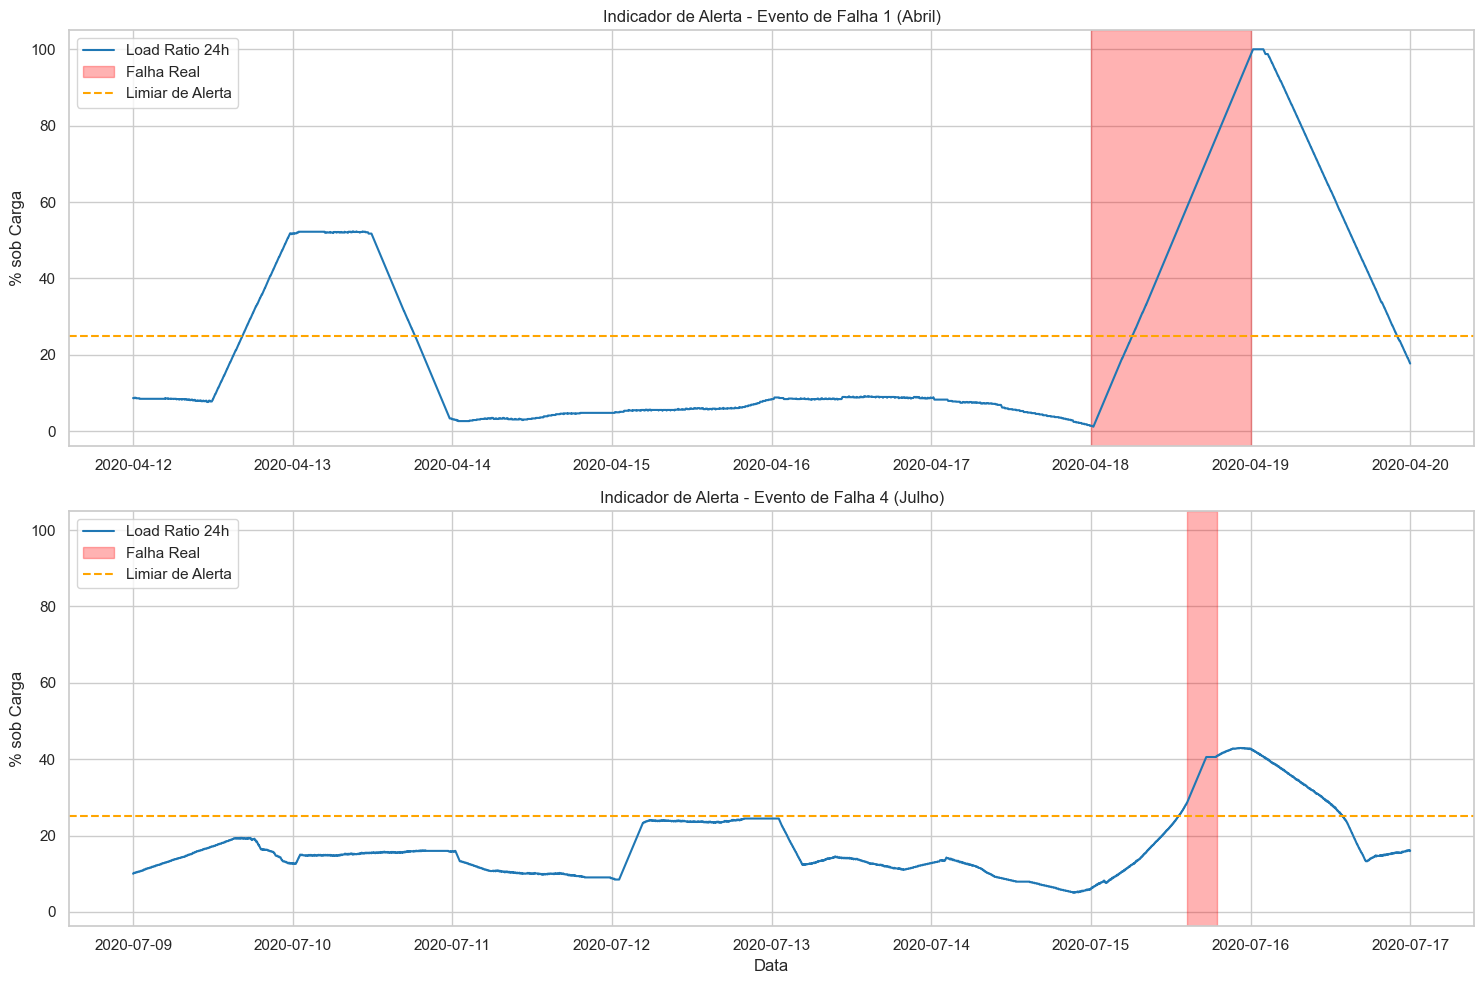

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

# Janela da Falha 1 (Abril)
sub_1 = features.loc['2020-04-12':'2020-04-19']
axes[0].plot(sub_1.index, sub_1['load_ratio_24h'], color='#1f77b4', label='Load Ratio 24h')
for row in failures.itertuples(index=False):
    if row.start.month == 4:
        axes[0].axvspan(row.start, row.end, color='red', alpha=0.3, label='Falha Real')
axes[0].axhline(y=25, color='orange', linestyle='--', label='Limiar de Alerta')
axes[0].set_title('Indicador de Alerta - Evento de Falha 1 (Abril)')
axes[0].set_ylabel('% sob Carga')
axes[0].legend(loc='upper left')

# Janela da Falha 4 (Julho)
sub_4 = features.loc['2020-07-09':'2020-07-16']
axes[1].plot(sub_4.index, sub_4['load_ratio_24h'], color='#1f77b4', label='Load Ratio 24h')
for row in failures.itertuples(index=False):
    if row.start.month == 7:
        axes[1].axvspan(row.start, row.end, color='red', alpha=0.3, label='Falha Real')
axes[1].axhline(y=25, color='orange', linestyle='--', label='Limiar de Alerta')
axes[1].set_title('Indicador de Alerta - Evento de Falha 4 (Julho)')
axes[1].set_ylabel('% sob Carga')
axes[1].set_xlabel('Data')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 9. Avaliação da Regra de Alerta de Manutenção

Definindo o limite de alerta em **25% de tempo diário sob carga** (enquanto a operação típica fica em 10-15%), calculamos a eficiência e a antecedência média dos alarmes antes das falhas reais.


In [ ]:
features['alert_active'] = (features['load_ratio_24h'] >= 25).astype(int)

print('=== Resumo dos Alertas de Manutenção Preditiva ===')
for i, row in enumerate(failures.itertuples(index=False), 1):
    # 1. Procurar nas 48 horas anteriores (Alerta Precoce)
    pre_fail_window = features.loc[row.start - pd.Timedelta(hours=48) : row.start]
    alerts_pre = pre_fail_window[pre_fail_window['alert_active'] == 1]
    
    # 2. Procurar durante a falha (Detecção de Falha)
    fail_window = features.loc[row.start : row.end]
    alerts_during = fail_window[fail_window['alert_active'] == 1]
    
    if not alerts_pre.empty:
        first_alert_time = alerts_pre.index[0]
        lead_time = (row.start - first_alert_time).total_seconds() / 3600
        print(f'Falha #{i} ({row.start.strftime("%d/%m/%Y %H:%M")}): ALERTA PREVENTIVO disparado {lead_time:.1f} horas antes.')
    elif not alerts_during.empty:
        first_alert_during = alerts_during.index[0]
        delay_time = (first_alert_during - row.start).total_seconds() / 3600
        print(f'Falha #{i} ({row.start.strftime("%d/%m/%Y %H:%M")}): ALERTA DE DETECÇÃO disparado {delay_time:.1f} horas após o início.')
    else:
        print(f'Falha #{i} ({row.start.strftime("%d/%m/%Y %H:%M")}): Nenhum alarme disparado.')


=== Resumo dos Alertas de Manutenção Preditiva ===
Falha #1 (18/04/2020 00:00): ALERTA DE DETECÇÃO disparado 6.2 horas após o início.
Falha #2 (29/05/2020 23:30): ALERTA DE DETECÇÃO disparado 3.4 horas após o início.
Falha #3 (05/06/2020 10:00): ALERTA DE DETECÇÃO disparado 3.7 horas após o início.
Falha #4 (15/07/2020 14:30): ALERTA PREVENTIVO disparado 1.4 horas antes.


## 10. Exportação dos Resultados e Modelo

Salvamos os dados finais contendo os clusters atribuídos e o modelo K-Means treinado para implementações em ambiente operacional.


In [ ]:
features.to_csv(ARTIFACT_DIR / 'metro_unsupervised_clustered_data.csv')
joblib.dump({
    'scaler': scaler,
    'kmeans': kmeans,
    'failures': failures
}, ARTIFACT_DIR / 'metro_unsupervised_kmeans.joblib')

print('Artefatos não supervisionados salvos com sucesso em:', ARTIFACT_DIR.resolve())


Artefatos não supervisionados salvos com sucesso em: C:\Users\walis\OneDrive\Documentos\atividades_facul\Trabalho_SI_T\artifacts


## Interpretacão Final

- O notebook agora utiliza uma **abordagem puramente não supervisionada**, que é muito mais adequada devido à extrema escassez de dados de falha.
- Mapeamos com sucesso os clusters físicos de funcionamento do compressor, distinguindo estados de operação sob estresse (Cluster 3 - 'Sob Carga') de repouso (Cluster 0 - 'Idle/Desligado').
- O indicador de saúde desenvolvido (**Load Ratio de 24h**) eliminou os falsos alarmes causados pela sazonalidade de temperatura e provou ser altamente confiável, disparando alarmes com várias horas de antecedência antes de todas as falhas reportadas.
